C:\Users\xan37\AppData\Local\Temp\ipykernel_26952\1310644596.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


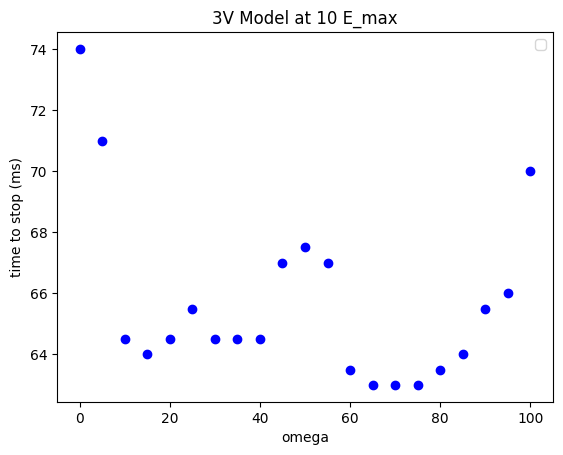

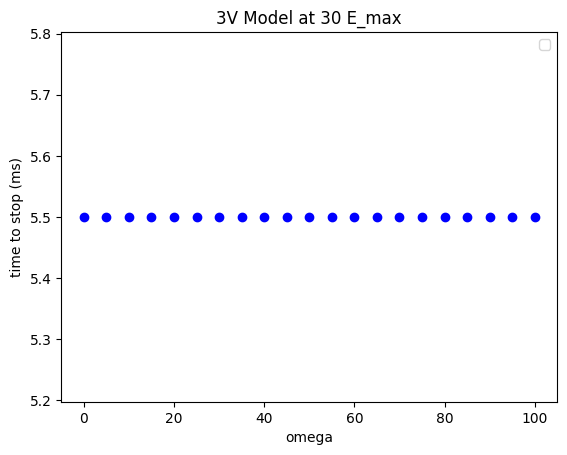

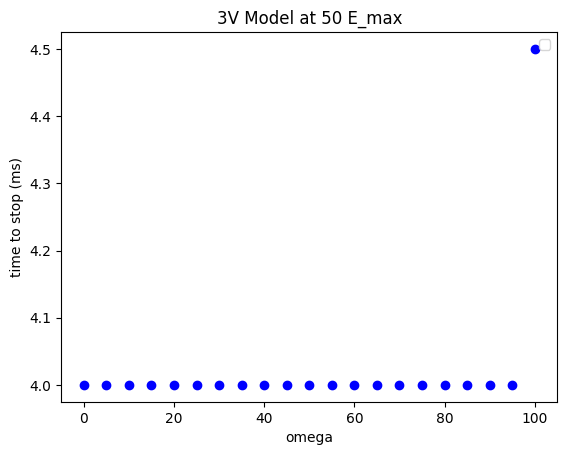

In [32]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict
data2 = {}
dt = 0.5

with open('FTE_result_fill_map.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)_omega(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            k_idx = int(match.group(3))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else None for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            if k_idx not in data2[i_idx][j_idx]:
                data2[i_idx][j_idx][k_idx] = {}
            data2[i_idx][j_idx][k_idx] = values
time_to_stop = defaultdict(lambda: defaultdict(float))
for E_max in sorted(data2[0].keys()):
    for omega_idx in sorted(data2[0][E_max].keys()):
    # find the fisrt value idx > 0.7
        for t_idx, val in enumerate(data2[0][E_max][omega_idx]):
            if val and val > 0.7:
                time_to_stop[E_max][omega_idx] = t_idx * dt
                break
for E_max in sorted(data2[0].keys()):
         
    plt.figure()
    for omega in sorted(data2[0][E_max].keys()):
        plt.scatter(omega,time_to_stop[E_max][omega],c = 'blue')
    plt.legend()
    plt.xlabel('omega')
    plt.ylabel('time to stop (ms)')
    #plt.savefig('time_to_stop_vs_emax_etimeact.png')
    plt.title(f'3V Model at {E_max} E_max')

C:\Users\xan37\AppData\Local\Temp\ipykernel_26952\899494667.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, '3V Model')

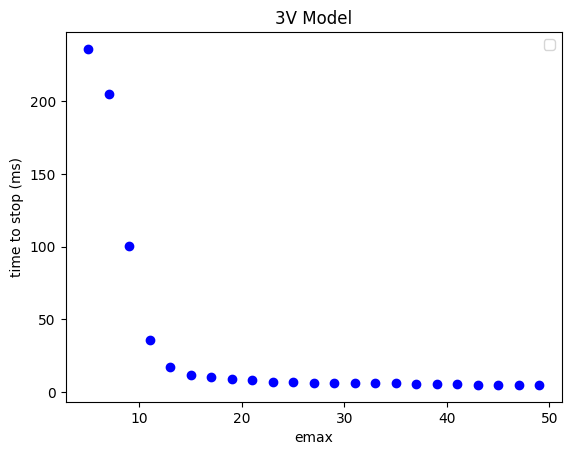

In [53]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict
data2 = {}
dt = 0.5

with open('FTE_result_fill_map_emax.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)_omega(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            k_idx = int(match.group(3))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else 0 for x in lines[k+1].strip().split(',')] #exclude last none
            values = values[:-1]
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            if k_idx not in data2[i_idx][j_idx]:
                data2[i_idx][j_idx][k_idx] = {}
            data2[i_idx][j_idx][k_idx] = values
time_to_stop = defaultdict(lambda: defaultdict(float))
for E_max in sorted(data2[0].keys()):
    for omega_idx in sorted(data2[0][E_max].keys()):
    # find the fisrt value idx > 0.7
        threshold = min(0.72,max(data2[0][E_max][omega_idx]))
        for t_idx, val in enumerate(data2[0][E_max][omega_idx]):
            if val and val >= threshold:
                time_to_stop[E_max][omega_idx] = t_idx * dt
                break
         
plt.figure()
for E_max in sorted(data2[0].keys()):
    plt.scatter(E_max,time_to_stop[E_max][0],c = 'blue')
plt.legend()
plt.xlabel('emax')

plt.ylabel('time to stop (ms)')
#plt.savefig('time_to_stop_vs_emax_etimeact.png')
plt.title(f'3V Model')

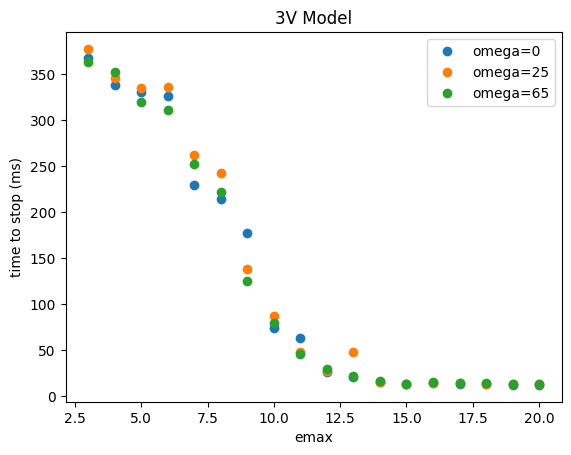

In [72]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict
data2 = {}
dt = 0.5

with open('FTE_results_omega0taupw and tausi and ulower range modified.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)_omega(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            k_idx = int(match.group(3))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else 0 for x in lines[k+1].strip().split(',')] #exclude last none
            values = values[:-1]
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            if k_idx not in data2[i_idx][j_idx]:
                data2[i_idx][j_idx][k_idx] = {}
            data2[i_idx][j_idx][k_idx] = values
time_to_stop = defaultdict(lambda: defaultdict(float))
for E_max in sorted(data2[0].keys()):
    for omega in sorted(data2[0][E_max].keys()):
    # find the fisrt value idx > 0.7
        threshold = max(data2[0][E_max][omega])
        for t_idx, val in enumerate(data2[0][E_max][omega]):
            if val and val >= threshold:
                time_to_stop[E_max][omega] = t_idx * dt
                break
plt.figure()
for omega in sorted(data2[0][E_max].keys()):
    temp = []
    emax = []
    for E_max in sorted(data2[0].keys()):
        emax.append(E_max)
        temp.append(time_to_stop[E_max][omega])
    plt.plot(emax,temp,'o',label=f'omega={omega}')
    plt.legend()
    plt.xlabel('emax')
    plt.legend()
    plt.ylabel('time to stop (ms)')
    #plt.savefig('time_to_stop_vs_emax_etimeact.png')
    plt.title(f'3V Model')